# Análise meus livros lidos

Este projeto tem como objetivo analisar meus hábitos de leitura a partir do histórico de 54 livros lidos (Até dia 11/08/2026)

A análise busca identificar padrões relacionados ao volume de leitura, gêneros, autores, avaliação e ritmo de leitura ao longo do tempo.

Perguntas que quero responder
- Como meu volume de leitura evoluiu ao longo dos anos?
- Quais gêneros leio mais?
- Quais autores aparecem com maior frequência?
- Como meu ritmo de leitura evoluiu?
- Existe relação entre tamanho do livro e tempo de leitura?
- Minha avaliação varia de acordo com gênero ou outras características?

# Preparação

## Import dos dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/lidos.csv", sep=";", encoding="latin1")

In [4]:
df.head()

,isbn,titulo,autor,paginas,ano_publicacao,genero,subgenero,tipo,pais_autor,nome_serie,num_serie,formato,avaliacao,data_inicio,data_termino,preco,data_compra,tipo_aquisicao,Status
0,9788581220307,Jogos Vorazes,Suzanne Collins,393,2008,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,1.0,Ebook,5.0,2022-10-13,2022-10-17,NaN,NaN,Kindle,concluido
1,9788580417661,Origem,Dan Brown,432,2017,Suspense,Investigativo,Ficção,Estados Unidos,NaN,NaN,Ebook,5.0,2021-06-13,2021-06-27,NaN,NaN,Kindle,concluido
2,9788576832478,Mazer Runner - Correr ou morrer,James Dashner,428,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Mazer Runner,1.0,Ebook,5.0,2020-09-20,2020-09-24,NaN,NaN,Kindle,concluido
3,9788599296677,Ponto de Impacto,Dan Brown,400,1993,Suspense,Policial,Ficção,Estados Unidos,NaN,NaN,Ebook,5.0,2021-04-22,2021-05-08,NaN,NaN,Kindle,concluido
4,9786555320749,Jogos Vorazes - Em Chamas,Suzanne Collins,416,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,2.0,Ebook,5.0,2026-02-02,2026-02-12,NaN,NaN,Kindle,concluido


## Estrutura

In [5]:
df.shape

(54, 19)

A amostra de dados possui 54 livros.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn            54 non-null     object 
 1   titulo          54 non-null     object 
 2   autor           54 non-null     object 
 3   paginas         54 non-null     int64  
 4   ano_publicacao  54 non-null     int64  
 5   genero          54 non-null     object 
 6   subgenero       54 non-null     object 
 7   tipo            54 non-null     object 
 8   pais_autor      54 non-null     object 
 9   nome_serie      7 non-null      object 
 10  num_serie       7 non-null      float64
 11  formato         54 non-null     object 
 12  avaliacao       54 non-null     float64
 13  data_inicio     54 non-null     object 
 14  data_termino    54 non-null     object 
 15  preco           10 non-null     object 
 16  data_compra     10 non-null     object 
 17  tipo_aquisicao  54 non-null     objec

In [7]:
df.describe()

,paginas,ano_publicacao,num_serie,avaliacao
count,54.000000,54.000000,7.000000,54.000000
mean,297.277778,1970.277778,1.571429,3.981481
std,108.442562,132.273076,0.786796,0.752123
min,64.000000,1087.000000,1.000000,1.500000
25%,242.250000,1972.750000,1.000000,3.500000
50%,310.500000,2009.000000,1.000000,4.000000
75%,377.750000,2018.750000,2.000000,4.500000
max,544.000000,2024.000000,3.000000,5.000000


Esta análise permite identificar algumas características iniciais do conjunto de dados e também possíveis problemas de qualidade. O dataset possui 54 livros, com média de 297 páginas e avaliação média de aproximadamente 3,98.

Entre os valores apresentados, destaca-se o ano mínimo de publicação de 1087, enquanto o valor máximo é 2024. Esse valor mínimo é provavelmente resultado de um erro de preenchimento, sendo necessário verificar o registro correspondente e corrigi-lo antes de prosseguir com as análises relacionadas ao ano de publicação.

In [8]:
df.isna().sum()

,0
isbn,0
titulo,0
autor,0
paginas,0
ano_publicacao,0
genero,0
subgenero,0
tipo,0
pais_autor,0
nome_serie,47


A análise de valores ausentes mostra que a maior parte das colunas está completamente preenchida. As exceções são nome_serie, num_serie, preco e data_compra.

As colunas **nome_serie** e **num_serie** possuem 47 valores ausentes, correspondentes aos livros que não fazem parte de uma série. Portanto, nesse caso, os valores ausentes são esperados e não representam necessariamente um problema de qualidade dos dados.

As colunas **preco** e **data_compra** possuem 44 valores ausentes. Esses valores serão investigados considerando também a coluna tipo_aquisicao, para verificar se a ausência está relacionada à forma como o livro foi adquirido, como presentes ou outras formas de aquisição em que essas informações não se aplicam.

In [9]:
df.duplicated().sum()

np.int64(0)

A análise de valores duplicados mostra que não existem colunas duplicadas no conjunto de dados.

## Limpeza/correção dos dados

Conversão para datetime

In [10]:
date_cols = ["data_inicio", "data_termino", "data_compra"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

As colunas de data foram convertidas para o formato datetime para permitir análises temporais e cálculo do período de leitura.

Ajuste coluna preço

In [11]:
df["preco"] = (
    df["preco"]
    .str.replace("R$", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.strip()
    .astype(float)
)

A coluna de preço foi convertida para aceitar os formatos diferentes que podem vir.

Vamos identificar a inconsistência que foi identificada no ano de publicação durante a análise descritiva.

In [12]:
df.loc[df["ano_publicacao"] < 1500, ["titulo", "autor", "ano_publicacao"]]

,titulo,autor,ano_publicacao
42,Misery,Stephen King,1087


O valor correto para o livro identificado com ano de publicação incorreto, é 1987. Será corrigido para as análises que irão utilizar o ano de publicação.

In [13]:
df.loc[df["titulo"] == "Misery", "ano_publicacao"] = 1987

In [14]:
df.loc[df["titulo"] == "Misery", ["titulo", "autor", "ano_publicacao"]]

,titulo,autor,ano_publicacao
42,Misery,Stephen King,1987


In [15]:
df["ano_publicacao"].min()

1818

O ano de 2023 não possui nenhuma leitura, então será identificado como 0 livros lidos. Para isso será criado uma variável "anos", para guardar todos os anos entre o primeiro livro concluído e o último

In [16]:
anos = range(
    df["data_termino"].dt.year.min(),
    df["data_termino"].dt.year.max() + 1
)

## Novas colunas

Criação da coluna dias_leitura, que calcula quandos dias se passaram entre a data de início e término da leitura. (Se o livro começou e terminou no mesmo dia conta como 1)

Não são necessáriamente os dias lidos, pois pode ter ocorrido pausas sem leitura, e sim a data que foi iniciado o livro e a data que foi concluído.

In [17]:
df["dias_de_leitura"] = (
    df["data_termino"] - df["data_inicio"]
).dt.days + 1

Criação da coluna paginas_por_dia, que cálcula quanta páginas em média foram lidas por dia.

In [18]:
df["paginas_por_dia"] = (
    df["paginas"] / df["dias_de_leitura"]
)

## Conjunto de dados pronto para a análise:

In [19]:
df.head()

,isbn,titulo,autor,paginas,ano_publicacao,genero,subgenero,tipo,pais_autor,nome_serie,...,formato,avaliacao,data_inicio,data_termino,preco,data_compra,tipo_aquisicao,Status,dias_de_leitura,paginas_por_dia
0,9788581220307,Jogos Vorazes,Suzanne Collins,393,2008,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,...,Ebook,5.0,2022-10-13,2022-10-17,NaN,NaT,Kindle,concluido,5,78.600000
1,9788580417661,Origem,Dan Brown,432,2017,Suspense,Investigativo,Ficção,Estados Unidos,NaN,...,Ebook,5.0,2021-06-13,2021-06-27,NaN,NaT,Kindle,concluido,15,28.800000
2,9788576832478,Mazer Runner - Correr ou morrer,James Dashner,428,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Mazer Runner,...,Ebook,5.0,2020-09-20,2020-09-24,NaN,NaT,Kindle,concluido,5,85.600000
3,9788599296677,Ponto de Impacto,Dan Brown,400,1993,Suspense,Policial,Ficção,Estados Unidos,NaN,...,Ebook,5.0,2021-04-22,2021-05-08,NaN,NaT,Kindle,concluido,17,23.529412
4,9786555320749,Jogos Vorazes - Em Chamas,Suzanne Collins,416,2009,Ficção Cientifica,Distopia,Ficção,Estados Unidos,Jogos Vorazes,...,Ebook,5.0,2026-02-02,2026-02-12,NaN,NaT,Kindle,concluido,11,37.818182


# Análise

## 1 - Evolução dos Hábitos de Leitura

### Quantidade de livros por ano

Como a quantidade de livros concluídos mudou ao longo dos anos?

In [20]:
livros_por_ano = (
    df.groupby(df["data_termino"].dt.year)["titulo"]
      .count()
      .reindex(anos, fill_value=0)
)

livros_por_ano

,titulo
data_termino,
2016,1
2017,1
2018,2
2019,1
2020,3
2021,9
2022,3
2023,0
2024,7


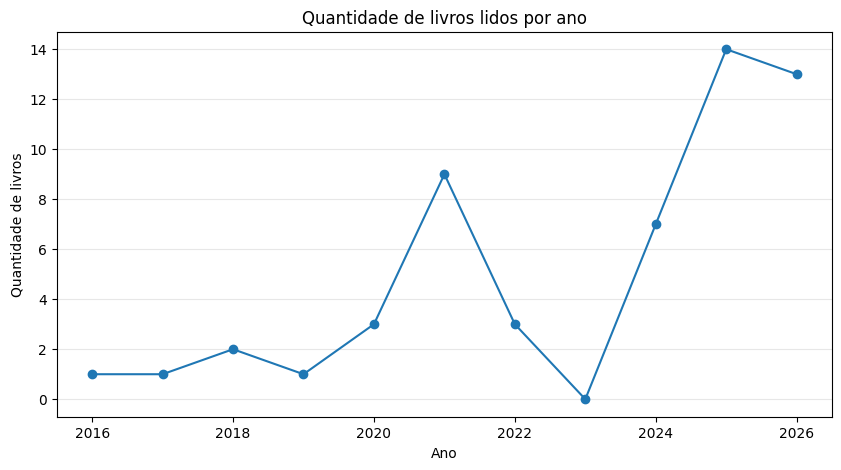

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    livros_por_ano.index,
    livros_por_ano.values,
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros lidos por ano")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Conclusão**: A quantidade de livros lidos apresentou um crescimento ao longo dos anos, com uma pausa na leitura no ano de 2023 e com um maior volume de leitura em 2025.
Esse resultado indica um aumento no número de livros concluídos, porém a quantidade de livros isoladamente não representa o volume total de leitura, já que os livros possuem diferentes quantidades de páginas.

### Quantidade de páginas por ano

Como a quantidade de páginas concluídas mudou ao longo dos anos?

In [22]:
paginas_por_ano = (
    df.groupby(df["data_termino"].dt.year)["paginas"]
      .sum()
      .reindex(anos, fill_value=0)
)

paginas_por_ano

,paginas
data_termino,
2016,310
2017,304
2018,669
2019,272
2020,985
2021,2181
2022,1065
2023,0
2024,2439


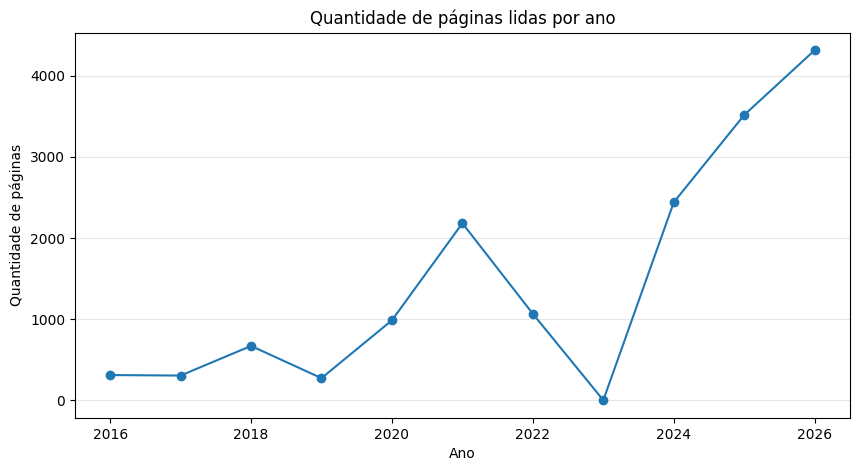

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    paginas_por_ano.index,
    paginas_por_ano.values,
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade de páginas")
plt.title("Quantidade de páginas lidas por ano")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Conclusão**: A quantidade de páginas lidas no ano também apresentou um crescimento ao longo dos anos e com uma pausa na leitura no ano de 2023. Porém teve um maior volume no ano de 2026, indicando que mesmo com menos livros lidos até a data da amostra, a quantidade de páginas foi maior.

### Evolução do volume de leitura

In [24]:
leitura_por_ano = (
    df.groupby(df["data_termino"].dt.year)
      .agg(
          livros_lidos=("titulo", "count"),
          paginas_lidas=("paginas", "sum")
      )
      .reindex(anos, fill_value=0)
)

leitura_por_ano

,livros_lidos,paginas_lidas
data_termino,,
2016,1,310
2017,1,304
2018,2,669
2019,1,272
2020,3,985
2021,9,2181
2022,3,1065
2023,0,0
2024,7,2439


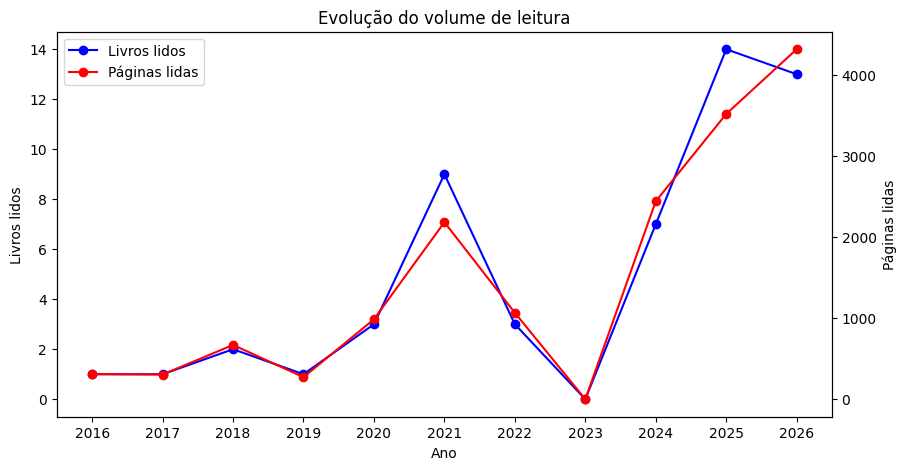

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    leitura_por_ano.index,
    leitura_por_ano["livros_lidos"],
    marker="o",
    color="blue",
    label="Livros lidos"
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Livros lidos")
ax1.set_xticks(leitura_por_ano.index)

ax2 = ax1.twinx()

ax2.plot(
    leitura_por_ano.index,
    leitura_por_ano["paginas_lidas"],
    marker="o",
    color="red",
    label="Páginas lidas"
)

ax2.set_ylabel("Páginas lidas")

linhas = ax1.lines + ax2.lines
labels = [linha.get_label() for linha in linhas]

ax1.legend(linhas, labels, loc="upper left")

plt.title("Evolução do volume de leitura")
plt.show()

**Conclusão**: A quantidade de páginas lidas apresenta uma tendência semelhante à quantidade de livros concluídos ao longo dos anos. No entanto, as duas métricas não evoluem de forma proporcional: em alguns períodos, o número de livros aumenta sem um crescimento equivalente no número de páginas, e vice-versa. Isso indica que a quantidade de livros concluídos, isoladamente, não representa completamente o volume de leitura.

### Evolução da velocidade de leitura

Como a velocidade de leitura evoluiu ao longo dos anos?

In [27]:
velocidade_leitura_por_ano = (
    df.groupby(df["data_termino"].dt.year)
      .agg(
          paginas_por_dia=("paginas_por_dia", "mean")
      )
      .reindex(anos, fill_value=0)
)

velocidade_leitura_por_ano

,paginas_por_dia
data_termino,
2016,1.448598
2017,1.420561
2018,6.118413
2019,9.714286
2020,47.196212
2021,41.899760
2022,36.380814
2023,0.000000
2024,38.394035


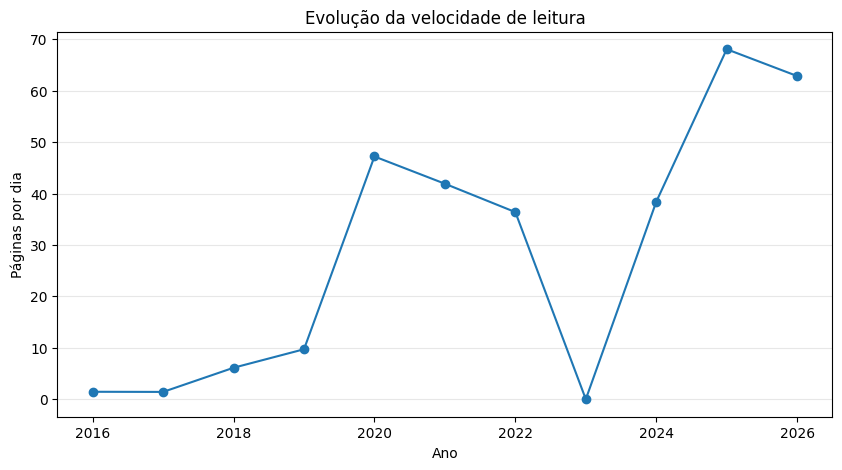

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    velocidade_leitura_por_ano.index,
    velocidade_leitura_por_ano["paginas_por_dia"],
    marker="o"
)

plt.xlabel("Ano")
plt.ylabel("Páginas por dia")
plt.title("Evolução da velocidade de leitura")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [31]:
ritmo_por_ano = (
    df.groupby(df["data_termino"].dt.year)["paginas_por_dia"]
      .agg(["count", "mean", "median"])
)

ritmo_por_ano

,count,mean,median
data_termino,,,
2016,1,1.448598,1.448598
2017,1,1.420561,1.420561
2018,2,6.118413,6.118413
2019,1,9.714286,9.714286
2020,3,47.196212,36.363636
2021,9,41.899760,28.800000
2022,3,36.380814,15.304348
2024,7,38.394035,33.090909
2025,14,68.054505,55.785714


**Conclusão**: A velocidade média de leitura apresentou queda entre 2020 e 2022, seguida de uma recuperação a partir de 2024. O maior aumento ocorreu em 2025, quando a média passou de 38,4 para 68,1 páginas por dia. Em 2026, o ritmo permaneceu elevado, com média de 62,8 páginas por dia. A mediana apresenta comportamento semelhante, reforçando que o aumento observado nos anos mais recentes não está concentrado apenas em alguns livros.

### Meses com maior volume de leitura

Existem alguns meses no ano em que leio mais? Ou leio menos?

In [33]:
meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}

meses_leitura = (
    df.groupby(df["data_termino"].dt.month)["titulo"]
      .count()
      .reindex(range(1, 13), fill_value=0)
)

meses_leitura.index = meses_leitura.index.map(meses)

meses_leitura

,titulo
data_termino,
Janeiro,5
Fevereiro,4
Março,2
Abril,9
Maio,6
Junho,3
Julho,4
Agosto,5
Setembro,3


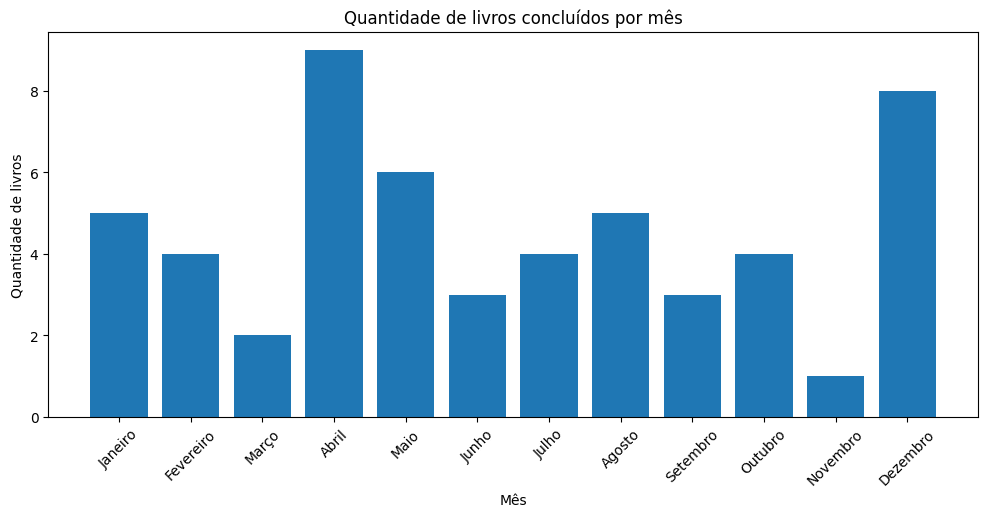

In [34]:
plt.figure(figsize=(12, 5))

plt.bar(meses_leitura.index, meses_leitura.values)

plt.xlabel("Mês")
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros concluídos por mês")

plt.xticks(rotation=45)
plt.show()

**Conclusão**: A quantidade de livros concluídos varia consideravelmente ao longo dos meses. Abril apresentou o maior volume de leituras, com 9 livros concluídos, seguido por dezembro, com 8. Novembro apresentou o menor volume, com apenas 1 livro. Apesar das diferenças observadas, não é possível identificar um padrão sazonal claro apenas com os dados disponíveis.

### Conclusão

Ao longo do período analisado, observa-se uma evolução no volume e no ritmo
de leitura, principalmente a partir de 2024. 2023 representa uma interrupção
no histórico, sem livros concluídos. Nos anos mais recentes, houve aumento
tanto na quantidade de livros e páginas lidas quanto na velocidade média de
leitura. Apesar das variações mensais, não foi identificado um padrão sazonal
claro no volume de livros concluídos.

## 2 -Perfil de leitura

### Distribuição por gênero

Qual gênero é mais lido?

In [35]:
generos_leitura = (
    df.groupby("genero")["titulo"]
      .count()
      .sort_values(ascending=False)
)

generos_leitura

,titulo
genero,
Suspense,19
Ficção Cientifica,14
Fantasia,6
Terror,6
Desenvolvimento Pessoal,4
Ficção,2
Biografia,1
Drama,1
Romance,1


Text(0.5, 1.0, 'Quantidade de livros por gênero')

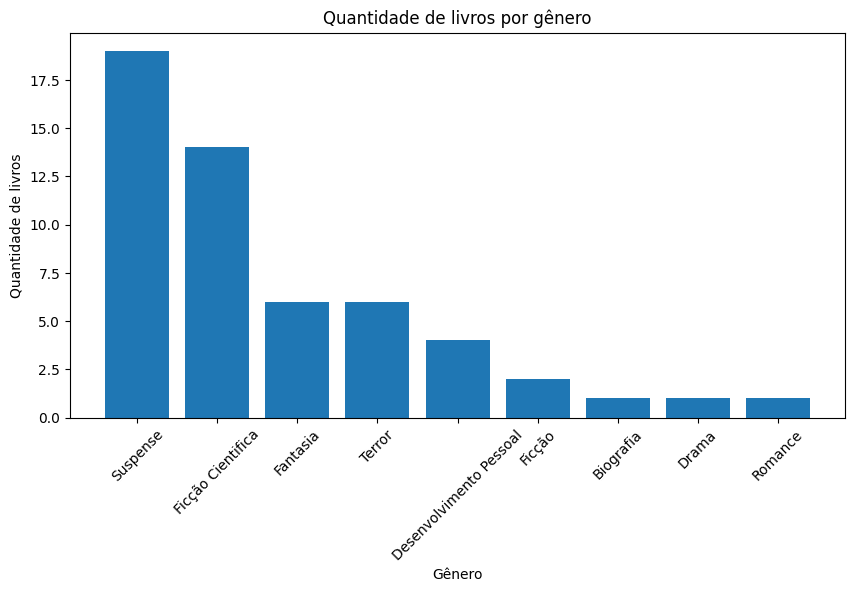

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(generos_leitura.index, generos_leitura.values)

plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por gênero")

Conclusão: Os gêneros mais lidos são Suspense e Ficção Ciêntifica, enquanto Biografia, Drama e Romance possuem menos livros liddos com apenas 1 de cada.

### Ficção x não ficção

Os tipos de livro mais lidos são ficção ou não ficção?

In [40]:
tipo_livro = (
    df.groupby("tipo")["titulo"]
      .count()
      .sort_values(ascending=False)
)

tipo_livro

,titulo
tipo,
Ficção,49
Não Ficção,5


Text(0.5, 1.0, 'Quantidade de livros por tipo')

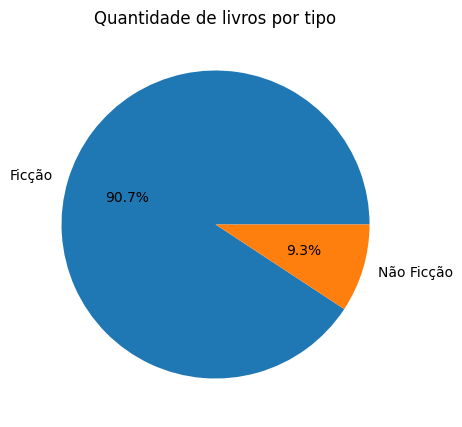

In [41]:
plt.figure(figsize=(10, 5))

plt.pie(
    tipo_livro.values,
    labels=tipo_livro.index,
    autopct="%1.1f%%"
)

plt.title("Quantidade de livros por tipo")

Conclusão: A leitura é fortemente concentrada em livros de Ficção, que representam 90,7% dos livros concluídos, enquanto a Não Ficção corresponde aos 9,3% restantes.

### Autores mais lidos

Quais os autores mais lidos?

In [43]:
autores_leitura = (
    df.groupby("autor")["titulo"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

autores_leitura

,titulo
autor,
Raphael Montes,6
James Dashner,3
Stephen King,3
Dan Brown,2
Blake Crouch,2
Neil Gaiman,2
Suzanne Collins,2
Júlio Verne,2
Freida McFadden,2


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

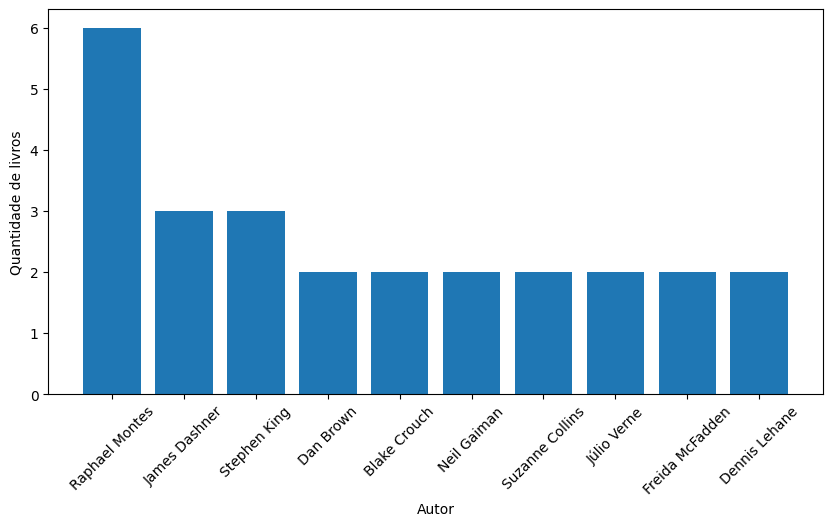

In [44]:
plt.figure(figsize=(10, 5))

plt.bar(autores_leitura.index, autores_leitura.values)

plt.xlabel("Autor")
plt.xticks(rotation=45)
plt.ylabel("Quantidade de livros")
plt.title("Quantidade de livros por autor")

Conclusão: O autor mais lido é Raphael Montes, seguido de James Dashner e Stephen King.

### Séries

Quais e quantos livros de uma série foram lidos?

In [45]:
series_leitura = (
    df.groupby("nome_serie")["titulo"]
      .count()
      .sort_values(ascending=False)
)

series_leitura

,titulo
nome_serie,
Mazer Runner,3
Jogos Vorazes,2
Harry Potter,1
A Empregada,1


Conclusão: Dentre as séries lidas, apenas Maze Runner teve a trilogia lida completa, enquanto nas outras, a série não foi terminada.

### Formato dos livros

### País do autor

Quais os países dos autores mais lidos?

### Ano de publicação dos livros

Os livros lidos estão mais concentrados em livros novos ou antigos?

## 3 - Ritmo e comportamento de leitura

### Tempo para concluir um livro

### Tamanho do livro x tempo de leitura

### Tamanho do livro x páginas/dia

### Gênero x velocidade de leitura

### Formato x velocidade de leitura

## 4 - Avaliações e preferências

### Avaliação média

### Gênero x avaliação

### Tamanho do livro x avaliação

### Formato x avaliação

### Evolução das avaliações

## 5- Insights finais

## Limitações
 - apenas 54 livros
 - dados pessoais
 - período relativamente curto
 - tempo de leitura baseado em início/fim
 - algumas categorias possuem poucos registros.